<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

'wget' is not recognized as an internal or external command,
operable program or batch file.


#### 2. Connect to the Database


**Install the needed libraries**


In [3]:
!pip install pandas

In [4]:
!pip install matplotlib

In [19]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [21]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [23]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [25]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


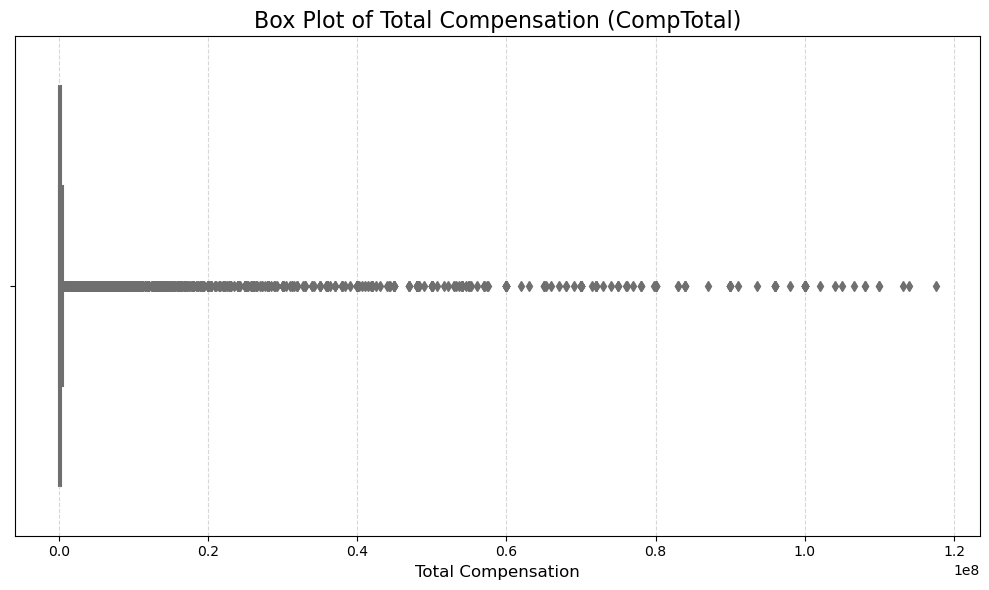

In [27]:
# your code goes here
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Connect to SQLite and load data
conn = sqlite3.connect("survey-data.sqlite")
QUERY = "SELECT CompTotal FROM main"
df = pd.read_sql_query(QUERY, conn)
conn.close()

# 2. Drop missing values
df = df.dropna(subset=['CompTotal'])

# 3. Convert to numeric
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')
df = df.dropna(subset=['CompTotal'])

# 4. Optional: Remove extreme outliers (top 1%)
df_filtered = df[df['CompTotal'] < df['CompTotal'].quantile(0.99)]

# 5. Plot box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_filtered['CompTotal'], color='skyblue')

plt.title("Box Plot of Total Compensation (CompTotal)", fontsize=16)
plt.xlabel("Total Compensation", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


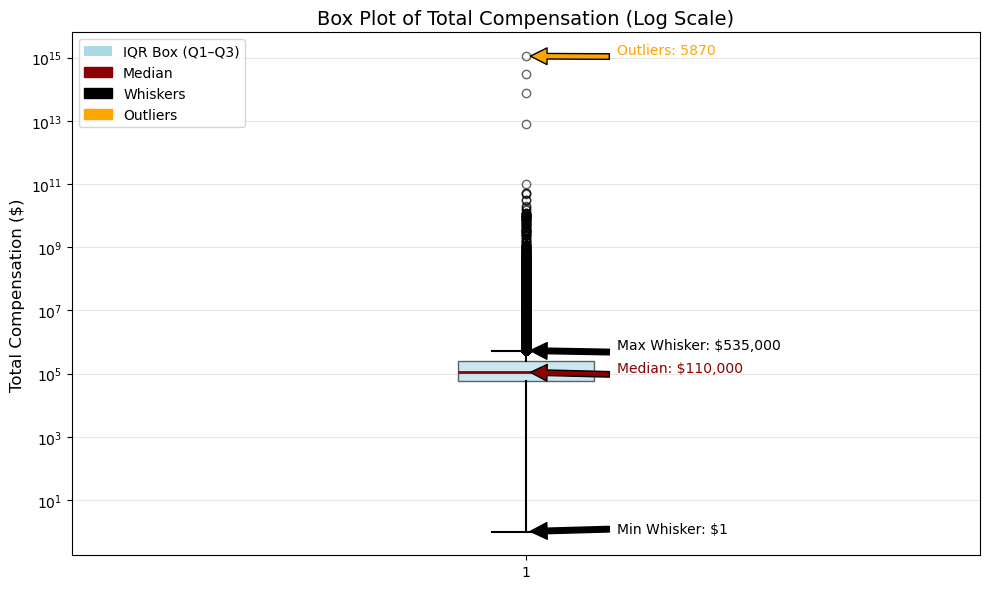

In [33]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re

# --- 1. Load CompTotal from SQLite ---
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT CompTotal FROM main", conn)
conn.close()

# --- 2. Clean CompTotal ---
def parse_compval(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'nan', 'n/a', 'na', 'none', 'null', 'unknown'}:
        return np.nan
    s = s.replace('$','').replace(',','').replace('\u200b','')
    s = s.replace('(','-').replace(')','')
    m = re.match(r'^([0-9]+(?:\.[0-9]+)?)k$', s)
    if m:
        return float(m.group(1))*1000
    nums = re.findall(r'-?\d+\.?\d*', s)
    if not nums:
        return np.nan
    nums = [float(n) for n in nums]
    return float(np.mean(nums))

df['CompTotal_clean'] = df['CompTotal'].map(parse_compval)
df['CompTotal_clean'] = pd.to_numeric(df['CompTotal_clean'], errors='coerce')

# --- 3. Keep only positive values for log-scale ---
comp_pos = df['CompTotal_clean'].dropna()
comp_pos = comp_pos[comp_pos > 0]

# --- 4. Plot log-scale boxplot ---
fig, ax = plt.subplots(figsize=(10,6))

box = ax.boxplot(comp_pos, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', alpha=0.6),
                 flierprops=dict(marker='o', markersize=6, color='orange', alpha=0.6),
                 medianprops=dict(color='darkred', linewidth=2),
                 whiskerprops=dict(color='black', linewidth=1.5),
                 capprops=dict(color='black', linewidth=1.5))

ax.set_yscale('log')
ax.set_title('Box Plot of Total Compensation (Log Scale)', fontsize=14)
ax.set_ylabel('Total Compensation ($)', fontsize=12)
ax.grid(axis='y', alpha=0.3, which='both')

# --- 5. Extract statistics for annotations ---
median_y = box['medians'][0].get_ydata()[0]
whisker_low = box['whiskers'][0].get_ydata()[1]
whisker_high = box['whiskers'][1].get_ydata()[1]
fliers = box['fliers'][0].get_ydata()

# Annotate median, whiskers, and outliers
ax.annotate(f'Median: ${median_y:,.0f}', xy=(1, median_y), xytext=(1.1, median_y*1.05),
            arrowprops=dict(facecolor='darkred', shrink=0.05), fontsize=10, color='darkred')
ax.annotate(f'Min Whisker: ${whisker_low:,.0f}', xy=(1, whisker_low), xytext=(1.1, whisker_low*0.9),
            arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, color='black')
ax.annotate(f'Max Whisker: ${whisker_high:,.0f}', xy=(1, whisker_high), xytext=(1.1, whisker_high*1.1),
            arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, color='black')
if len(fliers) > 0:
    ax.annotate(f'Outliers: {len(fliers)}', xy=(1, max(fliers)), xytext=(1.1, max(fliers)*1.2),
                arrowprops=dict(facecolor='orange', shrink=0.05), fontsize=10, color='orange')

# --- 6. Legend ---
legend_elements = [
    mpatches.Patch(facecolor='lightblue', label='IQR Box (Q1–Q3)'),
    mpatches.Patch(color='darkred', label='Median'),
    mpatches.Patch(color='black', label='Whiskers'),
    mpatches.Patch(color='orange', label='Outliers')
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()


**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


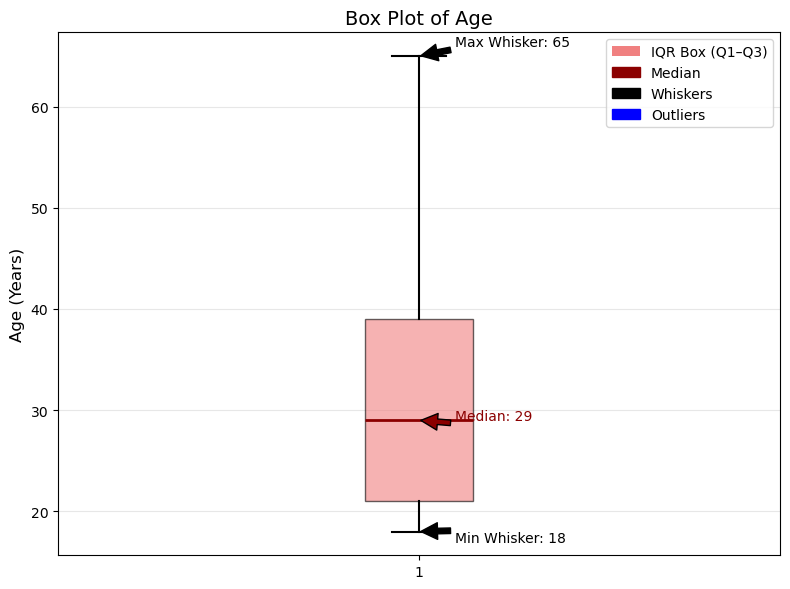

In [41]:
# your code goes here

# --- 1. Load Age from SQLite ---
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT Age FROM main", conn)
conn.close()

# --- 2. Clean and convert Age to numeric ---
def parse_age(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'nan', 'n/a', 'na', 'none', 'null', 'unknown', 'prefer not to say'}:
        return np.nan
    # Extract numbers from age ranges like "25-30"
    nums = re.findall(r'\d+', s)
    if not nums:
        return np.nan
    nums = [int(n) for n in nums]
    return int(np.mean(nums))  # Take average if a range is given

df['Age_clean'] = df['Age'].map(parse_age)

# Drop missing or invalid values
age_data = df['Age_clean'].dropna()

# --- 3. Plot boxplot ---
fig, ax = plt.subplots(figsize=(8,6))

box = ax.boxplot(age_data, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='lightcoral', alpha=0.6),
                 flierprops=dict(marker='o', markersize=6, color='blue', alpha=0.6),
                 medianprops=dict(color='darkred', linewidth=2),
                 whiskerprops=dict(color='black', linewidth=1.5),
                 capprops=dict(color='black', linewidth=1.5))

ax.set_title('Box Plot of Age', fontsize=14)
ax.set_ylabel('Age (Years)', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# --- 4. Extract statistics for annotations ---
median_y = box['medians'][0].get_ydata()[0]
whisker_low = box['whiskers'][0].get_ydata()[1]
whisker_high = box['whiskers'][1].get_ydata()[1]
fliers = box['fliers'][0].get_ydata()

# Annotate key statistics
ax.annotate(f'Median: {median_y:.0f}', xy=(1, median_y), xytext=(1.05, median_y),
            arrowprops=dict(facecolor='darkred', shrink=0.05), fontsize=10, color='darkred')
ax.annotate(f'Min Whisker: {whisker_low:.0f}', xy=(1, whisker_low), xytext=(1.05, whisker_low-1),
            arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, color='black')
ax.annotate(f'Max Whisker: {whisker_high:.0f}', xy=(1, whisker_high), xytext=(1.05, whisker_high+1),
            arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, color='black')
if len(fliers) > 0:
    ax.annotate(f'Outliers: {len(fliers)}', xy=(1, max(fliers)), xytext=(1.05, max(fliers)+1),
                arrowprops=dict(facecolor='blue', shrink=0.05), fontsize=10, color='blue')

# --- 5. Legend ---
legend_elements = [
    mpatches.Patch(facecolor='lightcoral', label='IQR Box (Q1–Q3)'),
    mpatches.Patch(color='darkred', label='Median'),
    mpatches.Patch(color='black', label='Whiskers'),
    mpatches.Patch(color='blue', label='Outliers')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()


### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


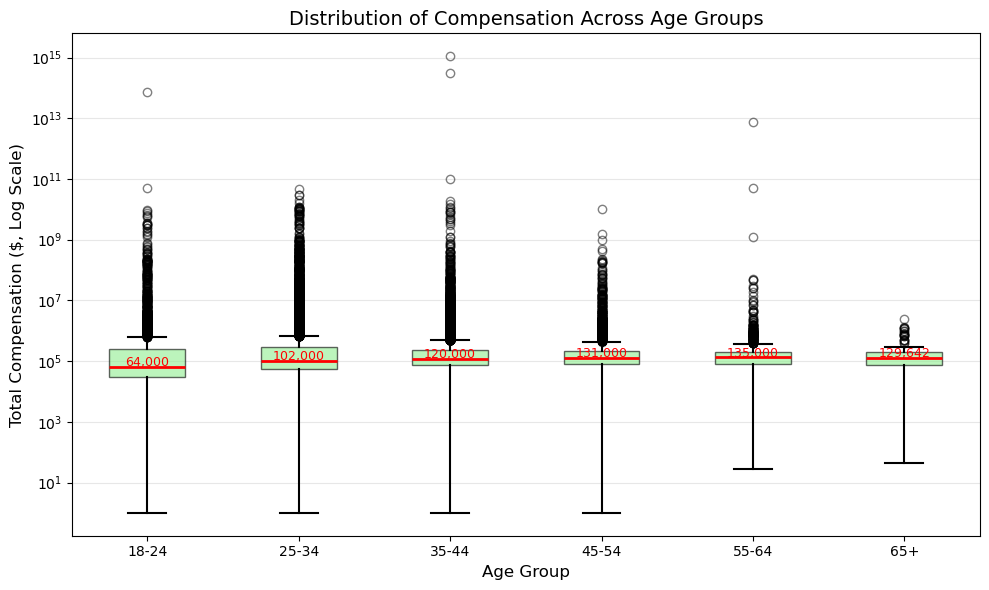

In [45]:
# your code goes here


# --- 1. Load Age and CompTotal ---
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT Age, CompTotal FROM main", conn)
conn.close()

# --- 2. Clean and convert Age ---
def parse_age(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'nan', 'n/a', 'na', 'none', 'null', 'unknown', 'prefer not to say'}:
        return np.nan
    nums = re.findall(r'\d+', s)
    if not nums:
        return np.nan
    nums = [int(n) for n in nums]
    return int(np.mean(nums))  # Take average if a range

df['Age_clean'] = df['Age'].map(parse_age)

# --- 3. Clean CompTotal ---
def parse_compval(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'nan', 'n/a', 'na', 'none', 'null', 'unknown'}:
        return np.nan
    s = s.replace('$','').replace(',','').replace('\u200b','')
    s = s.replace('(','-').replace(')','')
    m = re.match(r'^([0-9]+(?:\.[0-9]+)?)k$', s)
    if m:
        return float(m.group(1))*1000
    nums = re.findall(r'-?\d+\.?\d*', s)
    if not nums:
        return np.nan
    nums = [float(n) for n in nums]
    return float(np.mean(nums))

df['CompTotal_clean'] = df['CompTotal'].map(parse_compval)

# Keep only valid numeric values
df_plot = df.dropna(subset=['Age_clean', 'CompTotal_clean'])
df_plot = df_plot[df_plot['CompTotal_clean'] > 0]

# --- 4. Create Age Groups ---
age_bins = [18, 24, 34, 44, 54, 64, 100]
age_labels = ['18-24','25-34','35-44','45-54','55-64','65+']
df_plot['Age_Group'] = pd.cut(df_plot['Age_clean'], bins=age_bins, labels=age_labels, right=True)

# --- 5. Plot Box Plot ---
plt.figure(figsize=(10,6))
box = plt.boxplot(
    [df_plot[df_plot['Age_Group']==grp]['CompTotal_clean'] for grp in age_labels],
    labels=age_labels,
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen', alpha=0.6),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', color='blue', alpha=0.5),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5)
)

plt.yscale('log')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Total Compensation ($, Log Scale)', fontsize=12)
plt.title('Distribution of Compensation Across Age Groups', fontsize=14)
plt.grid(axis='y', alpha=0.3, which='both')

# --- 6. Optional: Add median annotations ---
for i, grp in enumerate(age_labels):
    med = df_plot[df_plot['Age_Group']==grp]['CompTotal_clean'].median()
    plt.text(i+1, med*1.05, f'{med:,.0f}', ha='center', color='red', fontsize=9)

plt.tight_layout()
plt.show()



**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


Min JobSat_clean: 0.0
Max JobSat_clean: 100.0
Number of unique JobSat_clean values: 90


C:\Users\praka\AppData\Local\Temp\ipykernel_19728\4207352770.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['JobSat_Bin'] = pd.cut(df_clean['JobSat_clean'], bins=bins, labels=labels, right=False, include_lowest=True)


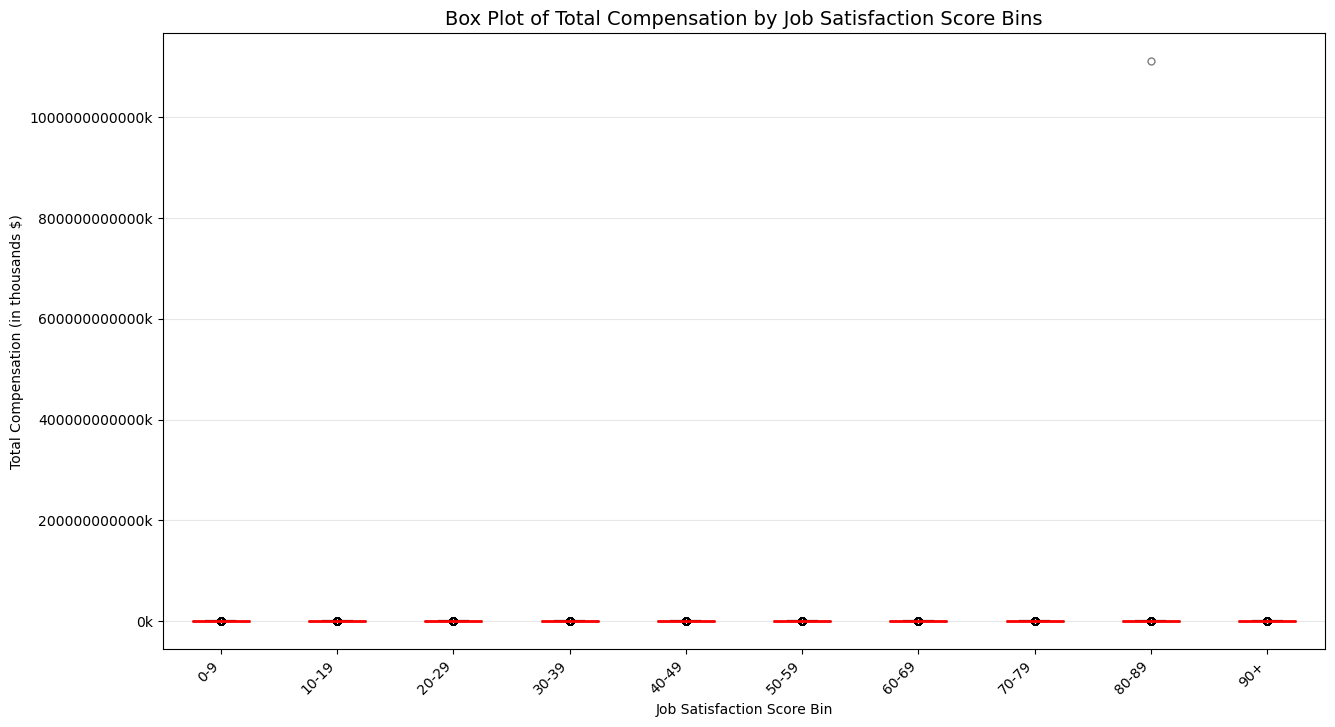

In [49]:
# your code goes here

import matplotlib.ticker as mtick

# --- 1. Load JobSatPoints_6 and CompTotal from SQLite ---
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT JobSatPoints_6, CompTotal FROM main", conn)
conn.close()

# --- 2. Clean CompTotal ---
def parse_compval(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'nan', 'n/a', 'na', 'none', 'null', 'unknown'}:
        return np.nan
    s = s.replace('$','').replace(',','').replace('\u200b','')
    s = s.replace('(','-').replace(')','')
    m = re.match(r'^([0-9]+(?:\.[0-9]+)?)k$', s)
    if m:
        return float(m.group(1))*1000
    nums = re.findall(r'-?\d+\.?\d*', s)
    if not nums:
        return np.nan
    nums = [float(n) for n in nums]
    return float(np.mean(nums))

df['CompTotal_clean'] = df['CompTotal'].map(parse_compval)

# --- 3. Clean JobSatPoints_6 ---
df['JobSat_clean'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Drop rows with missing values
df_clean = df.dropna(subset=['CompTotal_clean','JobSat_clean'])

# --- 4. Create Job Satisfaction Bins ---
# Let's create bins for JobSat_clean. We can inspect the range of values to decide on appropriate bins.
print("Min JobSat_clean:", df_clean['JobSat_clean'].min())
print("Max JobSat_clean:", df_clean['JobSat_clean'].max())
print("Number of unique JobSat_clean values:", df_clean['JobSat_clean'].nunique())

# Assuming JobSatPoints_6 is on a scale, let's create bins that represent ranges of satisfaction.
# For example, bins for low, medium, and high satisfaction, or more granular bins depending on the range.
# Based on previous inspections (or assuming a 0-100 scale), let's create bins in steps of 10 or 20.
bins = np.arange(0, df_clean['JobSat_clean'].max() + 10, 10) # Bins from 0 up to max + 10, in steps of 10
labels = [f'{i}-{i+9}' for i in bins[:-1]] # Labels like '0-9', '10-19', etc.
# Need to handle the last bin label appropriately based on the max value. Let's adjust labels.
labels = [f'{int(bins[i])}-{int(bins[i+1])-1}' for i in range(len(bins)-2)] + [f'{int(bins[-2])}+']


df_clean['JobSat_Bin'] = pd.cut(df_clean['JobSat_clean'], bins=bins, labels=labels, right=False, include_lowest=True)

# --- 5. Prepare data for box plot ---
# Get the unique job satisfaction bins
job_sat_bins = sorted(df_clean['JobSat_Bin'].dropna().unique())

# Create a list of CompTotal values for each JobSat bin
box_data = [df_clean[df_clean['JobSat_Bin']==b]['CompTotal_clean'].dropna() for b in job_sat_bins]

# Remove any empty lists in box_data (bins with no data) and corresponding labels
cleaned_box_data = [data for data in box_data if len(data) > 0]
cleaned_job_sat_bins = [job_sat_bins[i] for i in range(len(box_data)) if len(box_data[i]) > 0]


# --- 6. Plot Box Plot ---
plt.figure(figsize=(15,8)) # Increased figure size
plt.boxplot(cleaned_box_data,
            labels=cleaned_job_sat_bins,
            vert=True, # Vertical box plots
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markersize=5, color='green', alpha=0.5),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5)
           )

plt.title('Box Plot of Total Compensation by Job Satisfaction Score Bins', fontsize=14)
plt.xlabel('Job Satisfaction Score Bin') # Updated xlabel
plt.ylabel('Total Compensation (in thousands $)') # Updated ylabel
plt.grid(axis='y', alpha=0.3) # Grid on y-axis

# Format y-axis in thousands
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{int(x/1000)}k'))

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=45, ha='right')


plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


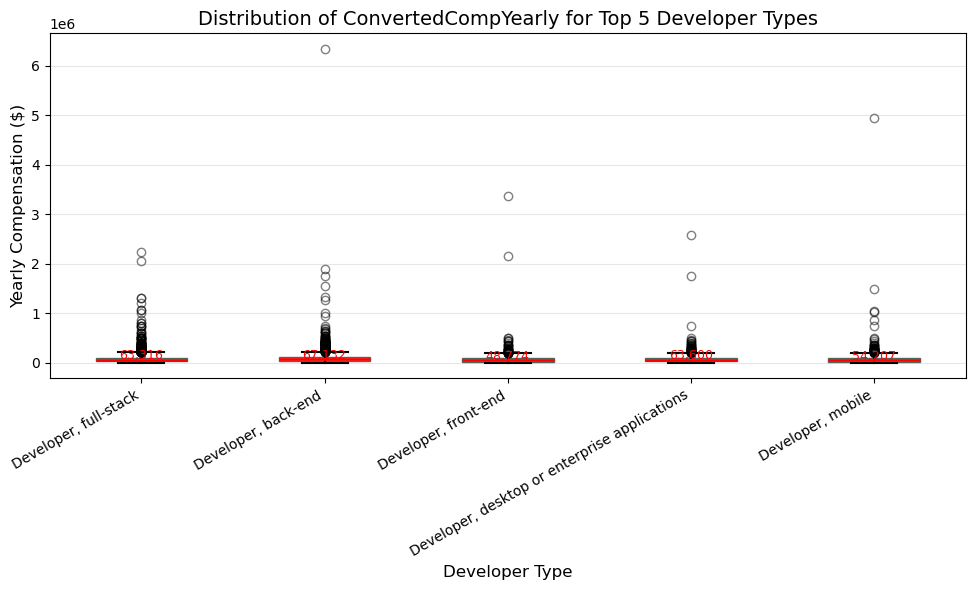

In [63]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# --- 1. Load DeveloperType and ConvertedCompYearly ---
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT DevType, ConvertedCompYearly FROM main", conn)
conn.close()

# --- 2. Clean ConvertedCompYearly ---
def parse_compval(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'nan', 'n/a', 'na', 'none', 'null', 'unknown'}:
        return np.nan
    s = s.replace('$','').replace(',','').replace('\u200b','')
    s = s.replace('(','-').replace(')','')
    m = re.match(r'^([0-9]+(?:\.[0-9]+)?)k$', s)
    if m:
        return float(m.group(1))*1000
    nums = re.findall(r'-?\d+\.?\d*', s)
    if not nums:
        return np.nan
    nums = [float(n) for n in nums]
    return float(np.mean(nums))

df['CompClean'] = df['ConvertedCompYearly'].map(parse_compval)
df = df.dropna(subset=['DevType', 'CompClean'])
df = df[df['CompClean'] > 0]

# --- 3. Identify Top 5 Developer Types ---
top5_devs = df['DevType'].value_counts().head(5).index.tolist()
df_top5 = df[df['DevType'].isin(top5_devs)]

# --- 4. Plot Box Plot (Linear Scale) ---
plt.figure(figsize=(10,6))

box = plt.boxplot(
    [df_top5[df_top5['DevType']==dev]['CompClean'] for dev in top5_devs],
    labels=top5_devs,
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen', alpha=0.6),
    medianprops=dict(color='red', linewidth=2),
    flierprops=dict(marker='o', color='blue', alpha=0.5),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5)
)

plt.xticks(rotation=30, ha='right')
plt.xlabel('Developer Type', fontsize=12)
plt.ylabel('Yearly Compensation ($)', fontsize=12)
plt.title('Distribution of ConvertedCompYearly for Top 5 Developer Types', fontsize=14)
plt.grid(axis='y', alpha=0.3)

# Optional: Annotate medians
for i, dev in enumerate(top5_devs):
    med = df_top5[df_top5['DevType']==dev]['CompClean'].median()
    plt.text(i+1, med*1.05, f'{med:,.0f}', ha='center', color='red', fontsize=9)

plt.tight_layout()
plt.show()


**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


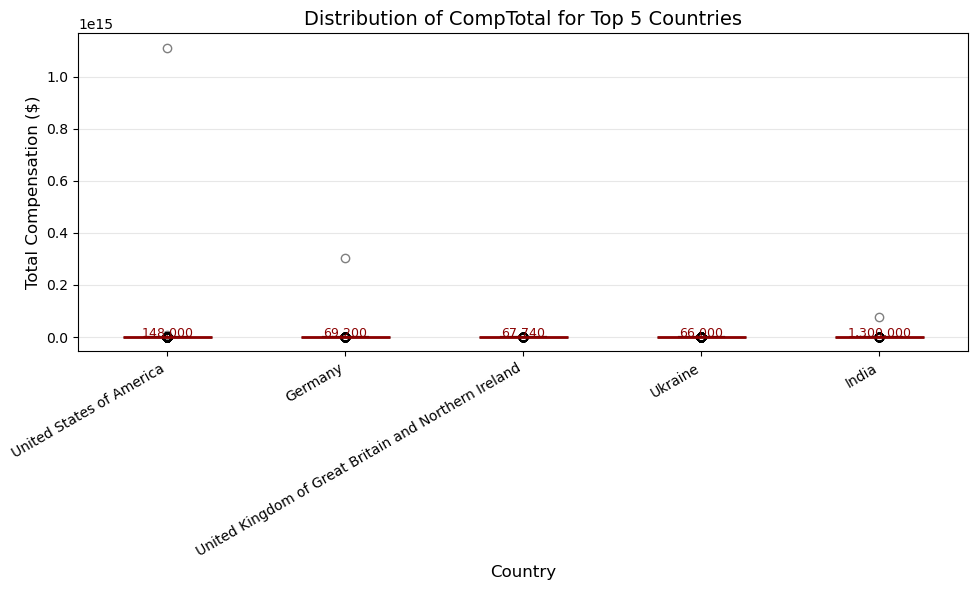

In [69]:
# your code goes here

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# --- 1. Load Country and CompTotal ---
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT Country, CompTotal FROM main", conn)
conn.close()

# --- 2. Clean CompTotal ---
def parse_compval(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'nan', 'n/a', 'na', 'none', 'null', 'unknown'}:
        return np.nan
    s = s.replace('$','').replace(',','').replace('\u200b','')
    s = s.replace('(','-').replace(')','')
    m = re.match(r'^([0-9]+(?:\.[0-9]+)?)k$', s)
    if m:
        return float(m.group(1))*1000
    nums = re.findall(r'-?\d+\.?\d*', s)
    if not nums:
        return np.nan
    nums = [float(n) for n in nums]
    return float(np.mean(nums))

df['CompTotal_clean'] = df['CompTotal'].map(parse_compval)

# Keep only valid numeric values
df = df.dropna(subset=['Country', 'CompTotal_clean'])
df = df[df['CompTotal_clean'] > 0]

# --- 3. Identify Top 5 Countries ---
top5_countries = df['Country'].value_counts().head(5).index.tolist()
df_top5 = df[df['Country'].isin(top5_countries)]

# --- 4. Plot Box Plot ---
plt.figure(figsize=(10,6))

box = plt.boxplot(
    [df_top5[df_top5['Country']==country]['CompTotal_clean'] for country in top5_countries],
    labels=top5_countries,
    patch_artist=True,
    boxprops=dict(facecolor='lightcoral', alpha=0.6),
    medianprops=dict(color='darkred', linewidth=2),
    flierprops=dict(marker='o', color='blue', alpha=0.5),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5)
)

plt.xticks(rotation=30, ha='right')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Compensation ($)', fontsize=12)
plt.title('Distribution of CompTotal for Top 5 Countries', fontsize=14)
plt.grid(axis='y', alpha=0.3)

# Optional: Annotate medians
for i, country in enumerate(top5_countries):
    med = df_top5[df_top5['Country']==country]['CompTotal_clean'].median()
    plt.text(i+1, med*1.05, f'{med:,.0f}', ha='center', color='darkred', fontsize=9)

plt.tight_layout()
plt.show()


### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


C:\Users\praka\AppData\Local\Temp\ipykernel_19728\639610582.py:58: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


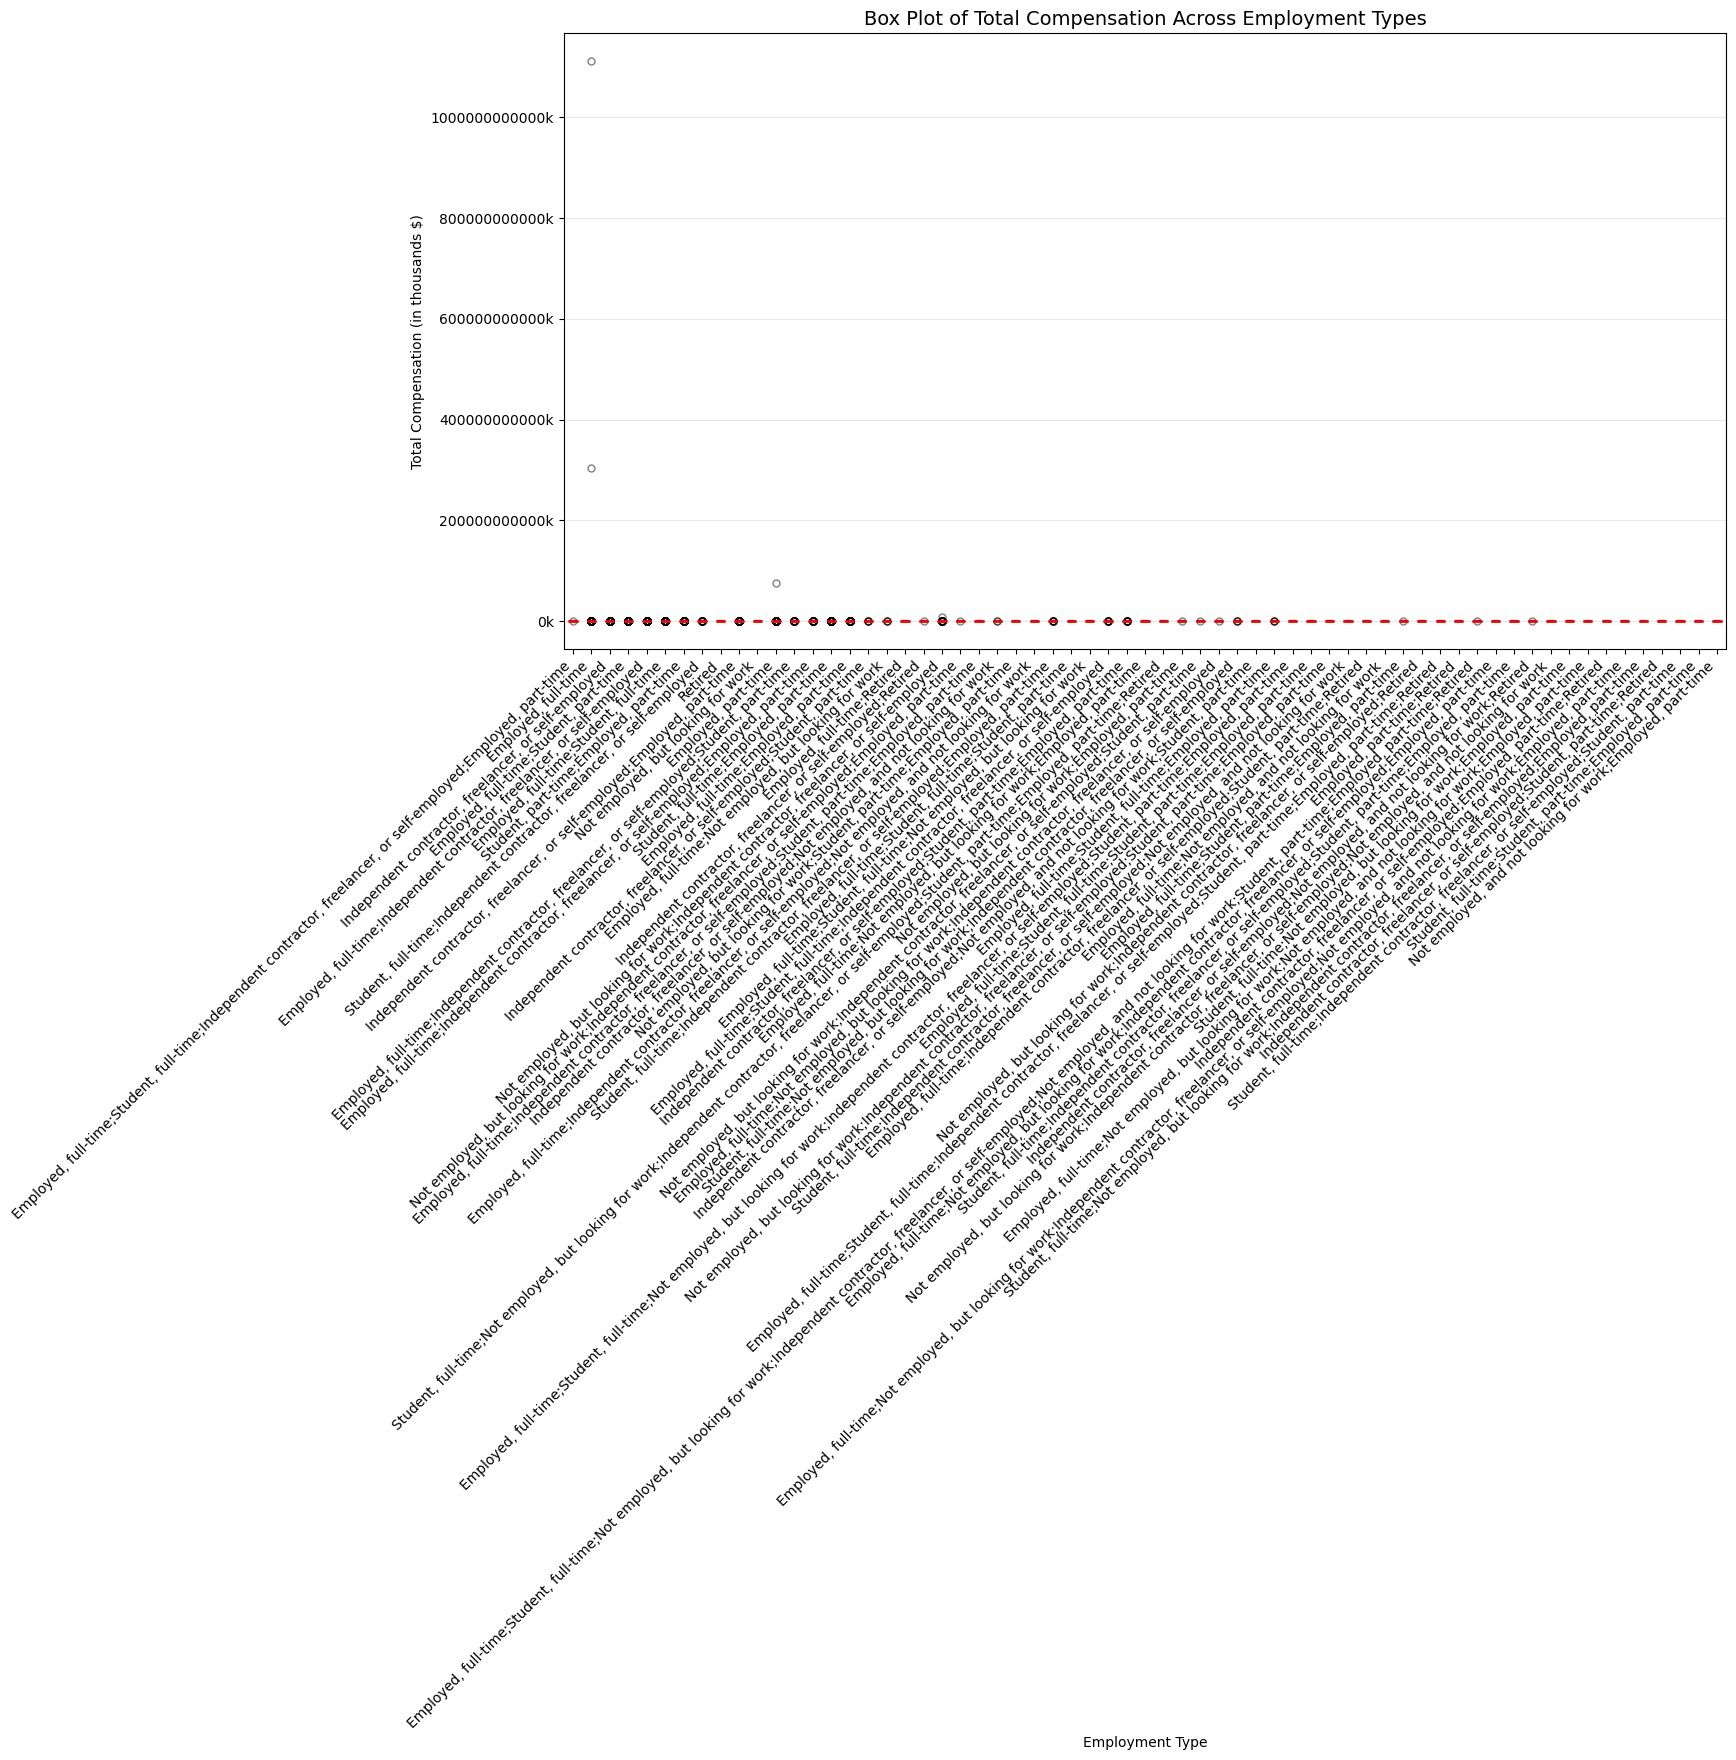

In [77]:
# your code goes here

conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT CompTotal, Employment FROM main", conn)
conn.close()

# --- 2. Clean CompTotal ---
def parse_compval(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'nan', 'n/a', 'na', 'none', 'null', 'unknown'}:
        return np.nan
    s = s.replace('$','').replace(',','').replace('\u200b','')
    s = s.replace('(','-').replace(')','')
    m = re.match(r'^([0-9]+(?:\.[0-9]+)?)k$', s)
    if m:
        return float(m.group(1))*1000
    nums = re.findall(r'-?\d+\.?\d*', s)
    if not nums:
        return np.nan
    nums = [float(n) for n in nums]
    return float(np.mean(nums))

df['Comp_clean'] = df['CompTotal'].map(parse_compval)

# --- 3. Drop rows with missing data ---
df_clean = df.dropna(subset=['Comp_clean','Employment'])

# --- 4. Get unique Employment types ---
employment_types = df_clean['Employment'].unique()

# --- 5. Prepare data for box plot ---
box_data = [df_clean[df_clean['Employment']==etype]['Comp_clean'] for etype in employment_types]

# --- 6. Plot box plot ---
plt.figure(figsize=(15,8))
plt.boxplot(box_data,
            labels=employment_types,
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markersize=5, color='green', alpha=0.5),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5)
           )

plt.title('Box Plot of Total Compensation Across Employment Types', fontsize=14)
plt.xlabel('Employment Type')
plt.ylabel('Total Compensation (in thousands $)')
plt.grid(axis='y', alpha=0.3)

# Format y-axis in thousands
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{int(x/1000)}k'))

plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels if long
plt.tight_layout()
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


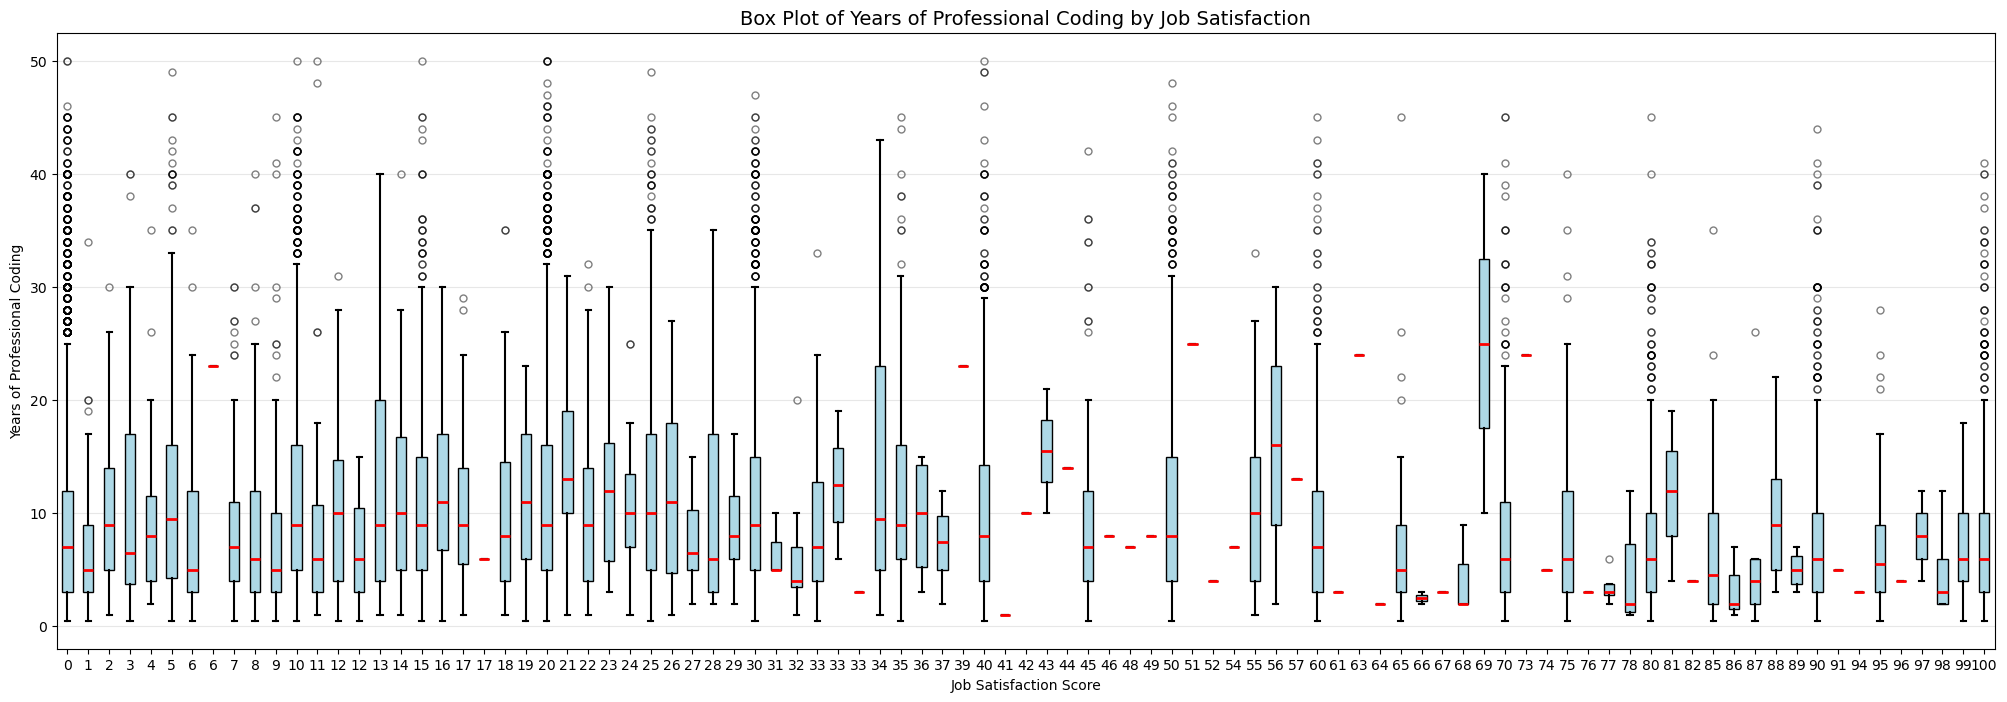

JobSat 0: median=7.0, mean=9.2, count=7503
JobSat 1: median=5.0, mean=7.4, count=39
JobSat 2: median=9.0, mean=10.0, count=41
JobSat 3: median=6.5, mean=11.5, count=36
JobSat 4: median=8.0, mean=9.5, count=26
JobSat 5: median=9.5, mean=11.3, count=674
JobSat 6: median=5.0, mean=8.7, count=49
JobSat 6: median=23.0, mean=23.0, count=1
JobSat 7: median=7.0, mean=8.7, count=117
JobSat 8: median=6.0, mean=8.3, count=145
JobSat 9: median=5.0, mean=8.2, count=117
JobSat 10: median=9.0, mean=11.3, count=3226
JobSat 11: median=6.0, mean=10.1, count=36
JobSat 12: median=10.0, mean=10.4, count=86
JobSat 12: median=6.0, mean=6.9, count=7
JobSat 13: median=9.0, mean=12.1, count=41
JobSat 14: median=10.0, mean=12.3, count=30
JobSat 15: median=9.0, mean=10.8, count=1434
JobSat 16: median=11.0, mean=12.3, count=36
JobSat 17: median=9.0, mean=10.8, count=43
JobSat 17: median=6.0, mean=6.0, count=1
JobSat 18: median=8.0, mean=10.1, count=55
JobSat 19: median=11.0, mean=11.0, count=21
JobSat 20: median=9

In [79]:
# --- 1. Load YearsCodePro and JobSatPoints_6 from SQLite ---
conn = sqlite3.connect('survey-data.sqlite')
df = pd.read_sql_query("SELECT YearsCodePro, JobSatPoints_6 FROM main", conn)
conn.close()

# --- 2. Clean YearsCodePro ---
def parse_years(x):
    """
    Convert YearsCodePro to numeric:
    - Handles ranges like '3-5' by taking mean
    - Converts 'Less than 1 year' to 0.5
    - Converts 'More than 50 years' to 50
    - Non-numeric / invalid -> NaN
    """
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {'', 'nan', 'n/a', 'na', 'none', 'unknown'}:
        return np.nan
    if s == 'less than 1 year':
        return 0.5
    if s == 'more than 50 years':
        return 50
    if '-' in s:
        parts = re.findall(r'\d+', s)
        if len(parts) == 2:
            return np.mean([float(parts[0]), float(parts[1])])
    try:
        return float(s)
    except:
        return np.nan

df['YearsCodePro_clean'] = df['YearsCodePro'].map(parse_years)

# --- 3. Clean JobSatPoints_6 ---
df['JobSat_clean'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# --- 4. Drop missing values ---
df_clean = df.dropna(subset=['YearsCodePro_clean','JobSat_clean'])

# --- 5. Prepare data for box plot ---
job_levels = sorted(df_clean['JobSat_clean'].unique())
box_data = [df_clean[df_clean['JobSat_clean']==level]['YearsCodePro_clean'] for level in job_levels]

# --- 6. Plot box plot ---
plt.figure(figsize=(25,8))
plt.boxplot(box_data,
            labels=[str(int(l)) for l in job_levels],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markersize=5, color='green', alpha=0.5),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5)
           )

plt.title('Box Plot of Years of Professional Coding by Job Satisfaction', fontsize=14)
plt.xlabel('Job Satisfaction Score')
plt.ylabel('Years of Professional Coding')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Optional: print statistics
for level in job_levels:
    data = df_clean[df_clean['JobSat_clean']==level]['YearsCodePro_clean']
    print(f"JobSat {int(level)}: median={data.median():.1f}, mean={data.mean():.1f}, count={len(data)}")

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [81]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
